# Δυναμικότητα Εργοστασίου έναντι Απόδοσης: Δισδιάστατη Ανάλυση Χαρτοφυλακίου με την PROC SGPLOT

## Περίληψη

Ένα χαρτοφυλάκιο παραγωγής διακριτής μεταποίησης έχει δύο αριθμούς που έχουν σημασία για κάθε γραμμή παραγωγής ταυτόχρονα: **πόση δυναμικότητα μηχανημάτων καταναλώνει** και **πόση καλή παραγωγή πραγματικά αποδίδει**. Ένα μονοδιάστατο ραβδόγραμμα μπορεί να δείξει μόνο το ένα από τα δύο. Αυτό το notebook οπτικοποιεί και τα δύο μαζί με την `PROC SGPLOT`, χρησιμοποιώντας ένα **διάγραμμα φυσαλίδων** ως κύρια προβολή — κάθε γραμμή τοποθετείται κατά δυναμικότητα (x) και απόδοση (y), με το μέγεθος της φυσαλίδας να κωδικοποιεί τον ρυθμό παραγωγικότητάς της (μονάδες ανά ώρα μηχανήματος). Γραμμές που βρίσκονται κάτω-δεξιά (πολλή δυναμικότητα, λίγη παραγωγή) είναι καταναλωτές δυναμικότητας· γραμμές που βρίσκονται πάνω-αριστερά με μεγάλη φυσαλίδα είναι υψηλής απόδοσης. Μια ομαδοποιημένη προβολή ράβδων στη συνέχεια αναλύει την απόδοση ανά εργοστάσιο, και μια κατάταξη παραγωγικότητας επιβεβαιώνει το χάσμα.

Με βάση την πραγματική εκτελεσμένη έξοδο (οκτώ γραμμές παραγωγής σε τρία εργοστάσια, 100 βάρδιες συγκεντρωμένες σε 24 κελιά γραμμής-εργοστασίου), η ανάλυση διαπιστώνει ότι η **Χύτευση** είναι ο πιο σαφής καταναλωτής δυναμικότητας του χαρτοφυλακίου (14.3 καλές μονάδες ανά ώρα μηχανήματος — απορροφά το 10.1% της συνολικής δυναμικότητας αλλά αποδίδει μόνο το 3.2% των καλών μονάδων) ενώ η **Συσκευασία** είναι η γραμμή υψηλής απόδοσης που ξεχωρίζει (119.2 μονάδες ανά ώρα — το 9.1% της δυναμικότητας επιστρέφει το 23.8% της παραγωγής). Μεταξύ των εργοστασίων, η **Στουτγάρδη** τρέχει πιο θερμά με 49.9 μονάδες/ώρα και η **Μοντερέι** πιο ψυχρά με 41.6.

## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|--------|
| WORK.PRODUCTION_RUNS | Συνθετικές παραγωγικές βάρδιες σε 8 γραμμές παραγωγής, 3 εργοστάσια και 3 βάρδιες — προγραμματισμένες ώρες μηχανήματος, ώρες λειτουργίας, διακοπές, ακαθάριστες/απορριπτόμενες/καλές μονάδες (περιορισμένο σε 100 παρατηρήσεις σε μη αδειοδοτημένη λειτουργία) | 100 |
| WORK.LINE_CAPACITY | Συγκεντρωτική σύνοψη ανά γραμμή παραγωγής και εργοστάσιο: συνολικές ώρες δυναμικότητας (x), καλές μονάδες που παρήχθησαν (y), και % απόδοσης αποδεκτών μονάδων | 24 |

*Όλα τα δεδομένα είναι συνθετικά και δημιουργούνται εντός του notebook με σταθερό seed — χωρίς εξωτερικά αρχεία, χωρίς δίκτυο.*

# Ανάλυση Δυναμικότητας Εργοστασίου έναντι Απόδοσης

**Τομέας:** Διακριτή μεταποίηση — λειτουργίες / βιομηχανική μηχανική

**Διαδικασία:** `PROC SGPLOT` (ODS Statistical Graphics)

Ένα συμβατικό ραβδόγραμμα δείχνει μία μόνο απόκριση ανά κατηγορία. Για να συγκρίνουμε ένα χαρτοφυλάκιο παραγωγής σε **δύο** αριθμητικές διαστάσεις ταυτόχρονα — *πόση δυναμικότητα καταναλώνει κάθε γραμμή παραγωγής* έναντι *πόση παραγωγή πραγματικά αποδίδει* — χρειαζόμαστε ένα γράφημα που τοποθετεί και τα δύο στον ίδιο καμβά. Η δήλωση `BUBBLE` της `PROC SGPLOT` κάνει ακριβώς αυτό: τοποθετεί κάθε γραμμή κατά δυναμικότητα (x) και καλές μονάδες (y) και αφήνει ένα τρίτο μέγεθος, τον ρυθμό παραγωγικότητας, να καθορίζει το μέγεθος της φυσαλίδας. Μια γραμμή που βρίσκεται πολύ δεξιά αλλά χαμηλά είναι καταναλωτής δυναμικότητας· μια γραμμή που βρίσκεται ψηλά και αριστερά με μια χοντρή φυσαλίδα είναι μια γραμμή υψηλής απόδοσης που αξίζει να προστατευτεί. Αυτό το notebook κατασκευάζει ένα ρεαλιστικό συνθετικό σύνολο δεδομένων παραγωγής και οδηγεί την SGPLOT μέσα από ένα διάγραμμα φυσαλίδων, ένα ραβδόγραμμα ομαδοποιημένο ανά εργοστάσιο, μια ανάλυση ενός εργοστασίου, και μια σύγκριση εργοστασίων δίπλα-δίπλα με ομαδοποιημένες ράβδους.

> **Σημείωση για την PROC GAREABAR.** Ο κλασικός τρόπος του SAS/GRAPH για την κωδικοποίηση δύο διαστάσεων ανά *ράβδο* είναι η `PROC GAREABAR` (ένα γράφημα area-bar αποκλειστικά ActiveX όπου το πλάτος της ράβδου κωδικοποιεί μία μεταβλητή και το ύψος μια άλλη). Η GAREABAR **δεν έχει ακόμη υλοποιηθεί σε αυτή την έκδοση του Jenner** — το κενό παρακολουθείται από το αποθηκευμένο τεστ `tests/400996_nb_gareabar_unimplemented`. Αυτό το notebook επιτυγχάνει τον ίδιο αναλυτικό στόχο με την πλήρως υποστηριζόμενη `PROC SGPLOT`, της οποίας οι προβολές φυσαλίδων και ομαδοποιημένων ράβδων μεταφέρουν την ίδια ιστορία δυναμικότητας-έναντι-απόδοσης.

## 1. Δημιουργία συνθετικών δεδομένων παραγωγής

Προσομοιώνουμε έξι εβδομάδες παραγωγικών βαρδιών για ένα δίκτυο διακριτής μεταποίησης τριών εργοστασίων. Κάθε γραμμή παραγωγής έχει έναν βασικό χρόνο κύκλου και ποσοστό απόρριψης· η απόδοση καθορίζεται από τις προγραμματισμένες ώρες μηχανήματος, την ειδική απόδοση ανά γραμμή, και τυχαίες διακοπές. Το `call streaminit` καθορίζει το seed ώστε το notebook να είναι πλήρως αναπαραγώγιμο — χωρίς εξωτερικά αρχεία, χωρίς δίκτυο.

In [1]:
/* --------------------------------------------------------
   Συνθετικές παραγωγικές βάρδιες
   8 γραμμές παραγωγής x 3 εργοστάσια x 3 βάρδιες x ~10 ημέρες
   width var  = προγραμματισμένες ώρες μηχανήματος (δυναμικότητα)
   response   = καλές μονάδες που παρήχθησαν (απόδοση)
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.production_runs;
    CALL streaminit(20260531);
    LENGTH product_line $30 plant $24 shift $28;

    /* ονομαστικές μονάδες ανά ώρα μηχανήματος, ανά γραμμή */
    ARRAY line_rate[8] _temporary_
        (42 28 35 18 60 75 90 140);
    /* βασικό ποσοστό απόρριψης ανά γραμμή */
    ARRAY line_scrap[8] _temporary_
        (0.04 0.06 0.05 0.09 0.03 0.02 0.02 0.01);
    /* συντελεστής απόδοσης εργοστασίου */
    ARRAY plant_eff[3] _temporary_ (1.00 0.92 1.08);
    ARRAY shift_eff[3] _temporary_ (1.00 0.95 0.88);

    ΕΠΑΝΑΛΗΨΗ day = 1 ΕΩΣ 10;
        ΕΠΑΝΑΛΗΨΗ li = 1 ΕΩΣ 8;
            ΕΠΑΝΑΛΗΨΗ pi = 1 ΕΩΣ 3;
                ΕΠΑΝΑΛΗΨΗ si = 1 ΕΩΣ 3;
                    ΕΑΝ      li = 1 ΤΟΤΕ product_line = "Πρεσάρισμα";
                    ΑΛΛΙΩΣ ΕΑΝ li = 2 ΤΟΤΕ product_line = "Συγκόλληση";
                    ΑΛΛΙΩΣ ΕΑΝ li = 3 ΤΟΤΕ product_line = "Κατεργασία";
                    ΑΛΛΙΩΣ ΕΑΝ li = 4 ΤΟΤΕ product_line = "Χύτευση";
                    ΑΛΛΙΩΣ ΕΑΝ li = 5 ΤΟΤΕ product_line = "Έγχυση";
                    ΑΛΛΙΩΣ ΕΑΝ li = 6 ΤΟΤΕ product_line = "Συναρμολόγηση";
                    ΑΛΛΙΩΣ ΕΑΝ li = 7 ΤΟΤΕ product_line = "Φινίρισμα";
                    ΑΛΛΙΩΣ ΕΑΝ li = 8 ΤΟΤΕ product_line = "Συσκευασία";

                    ΕΑΝ      pi = 1 ΤΟΤΕ plant = "Ντιτρόιτ";
                    ΑΛΛΙΩΣ ΕΑΝ pi = 2 ΤΟΤΕ plant = "Μοντερέι";
                    ΑΛΛΙΩΣ ΕΑΝ pi = 3 ΤΟΤΕ plant = "Στουτγάρδη";

                    ΕΑΝ      si = 1 ΤΟΤΕ shift = "Πρωινή";
                    ΑΛΛΙΩΣ ΕΑΝ si = 2 ΤΟΤΕ shift = "Απογευματινή";
                    ΑΛΛΙΩΣ ΕΑΝ si = 3 ΤΟΤΕ shift = "Νυχτερινή";

                    /* προγραμματισμένες ώρες μηχανήματος για τη βάρδια */
                    sched_hours = round(6.5 + rand('uniform') * 1.5, 0.1);

                    /* απρογραμμάτιστη διακοπή μειώνει τη δυναμικότητα */
                    downtime_hours =
                        round(rand('uniform') * 1.2
                              * (2 - plant_eff[pi]), 0.1);
                    run_hours = MAX(sched_hours - downtime_hours, 0.5);

                    /* ενεργός ρυθμός απόδοσης με θόρυβο */
                    eff = plant_eff[pi] * shift_eff[si]
                          * (0.9 + rand('uniform') * 0.2);
                    gross_units =
                        round(run_hours * line_rate[li] * eff);

                    scrap_rate = line_scrap[li]
                                 * (0.7 + rand('uniform') * 0.6);
                    scrap_units = round(gross_units * scrap_rate);
                    good_units  = gross_units - scrap_units;

                    run_date = '05JAN2026'd + (day - 1);
                    ΕΞΟΔΟΣ;
                ΤΕΛΟΣ;
            ΤΕΛΟΣ;
        ΤΕΛΟΣ;
    ΤΕΛΟΣ;
    ΚΡΑΤΗΣΗ run_date product_line plant shift
         sched_hours run_hours downtime_hours
         gross_units scrap_units good_units;
    ΜΟΡΦΗ run_date date9.;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=work.production_runs(obs=8) noobs;
    ΕΤΙΚΕΤΑ run_date="Ημερομηνία" product_line="Γραμμή παραγωγής" plant="Εργοστάσιο"
          shift="Βάρδια" sched_hours="Προγραμμ. ώρες" run_hours="Ώρες λειτουργίας"
          downtime_hours="Ώρες διακοπής" gross_units="Ακαθάρ. μονάδες"
          scrap_units="Απορριπτ. μονάδες" good_units="Καλές μονάδες";
    TITLE "Δείγμα Συνθετικών Δεδομένων Παραγωγής ανά Βάρδια";
ΕΚΤΕΛΕΣΗ;
TITLE;


                                    Δείγμα Συνθετικών Δεδομένων Παραγωγής ανά Βάρδια                                    

          Ημερομηνία                 Γραμμή παραγωγής            Εργοστάσιο                    Βάρδια              Προγραμμ. ώρες                 Ώρες λειτουργίας              Ώρες διακοπής               Ακαθάρ. μονάδες                 Απορριπτ. μονάδες              Καλές μονάδες
           05JAN2026  Πρεσάρισμα                       Ντιτρόιτ              Πρωινή                                           7.8                              6.7                        1.1                           306                                14                        292
           05JAN2026  Πρεσάρισμα                       Ντιτρόιτ              Απογευματινή                                     6.8                              6.5                        0.3                           259                                12                        247
           05JAN2026  Πρεσάρισμα   


NOTE: DATA work.production_runs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.production_runs (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.25 seconds
  cpu   0.25 seconds
NOTE: PROC PRINT data=work.production_runs

NOTE: PROC PRINT completed: 8 observations printed, 10 variables


## 2. Συγκέντρωση στο επίπεδο γραμμής-εργοστασίου

Τα γραφήματα συγκρίνουν ένα σημείο ανά κατηγορία, οπότε συγκεντρώνουμε τη λεπτομέρεια σε επίπεδο βάρδιας σε μια σύνοψη ανά γραμμή παραγωγής και εργοστάσιο. Το `total_capacity` (άθροισμα προγραμματισμένων ωρών μηχανήματος) γίνεται η διάσταση **x**, το `good_units` (άθροισμα αποδεκτής παραγωγής) η διάσταση **y**, και το `units_per_hr` (καλές μονάδες ÷ ώρες δυναμικότητας) ο ρυθμός παραγωγικότητας που θα καθορίσει το μέγεθος των φυσαλίδων. Διατηρούμε το `plant` ώστε να μπορεί να χρησιμεύσει αργότερα ως μεταβλητή ομαδοποίησης. Κατασκευάζουμε επίσης μια συγκέντρωση σε επίπεδο γραμμής (σε όλα τα εργοστάσια) για το διάγραμμα φυσαλίδων χαρτοφυλακίου.

In [2]:
/* --------------------------------------------------------
   Συγκέντρωση σε επίπεδο product_line x plant
   total_capacity -> x (ώρες δυναμικότητας)
   good_units     -> y (απόδοση)
   units_per_hr   -> μέγεθος φυσαλίδας (παραγωγικότητα)
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.production_runs NOPRINT NWAY;
    ΚΛΑΣΗ product_line plant;
    ΜΕΤΑΒΛΗΤΗ sched_hours good_units scrap_units;
    ΕΞΟΔΟΣ out=work.line_capacity(ΑΦΑΙΡΕΣΗ=_type_ _freq_)
        sum(sched_hours)  = total_capacity
        sum(good_units)   = good_units
        sum(scrap_units)  = scrap_units;
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ work.line_capacity;
    ΟΡΙΣΜΟΣ work.line_capacity;
    units_per_hr = good_units / total_capacity;
    yield_pct    = 100 * good_units / (good_units + scrap_units);
    ΜΟΡΦΗ units_per_hr 6.1 yield_pct 5.1;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=work.line_capacity;
    ΚΑΤΑ product_line plant;
ΕΚΤΕΛΕΣΗ;

/* Συγκέντρωση σε επίπεδο γραμμής (σε όλα τα εργοστάσια) για το χαρτοφυλάκιο */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.line_capacity NOPRINT NWAY;
    ΚΛΑΣΗ product_line;
    ΜΕΤΑΒΛΗΤΗ total_capacity good_units;
    ΕΞΟΔΟΣ out=work.line_total(ΑΦΑΙΡΕΣΗ=_type_ _freq_)
        sum(total_capacity) = total_capacity
        sum(good_units)     = good_units;
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ work.line_total;
    ΟΡΙΣΜΟΣ work.line_total;
    units_per_hr = good_units / total_capacity;
    ΜΟΡΦΗ units_per_hr 6.1;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=work.line_total;
    ΚΑΤΑ units_per_hr;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=work.line_total noobs;
    ΜΕΤΑΒΛΗΤΗ product_line total_capacity good_units units_per_hr;
    ΕΤΙΚΕΤΑ product_line="Γραμμή παραγωγής" total_capacity="Συνολικές ώρες δυναμικότητας"
          good_units="Καλές μονάδες" units_per_hr="Μονάδες/ώρα";
    TITLE "Γραμμές Χαρτοφυλακίου Κατά Σειρά Παραγωγικότητας (καλές μονάδες ανά ώρα μηχανήματος)";
ΕΚΤΕΛΕΣΗ;
TITLE;


                  Γραμμές Χαρτοφυλακίου Κατά Σειρά Παραγωγικότητας (καλές μονάδες ανά ώρα μηχανήματος)                  

               Γραμμή παραγωγής                            Συνολικές ώρες δυναμικότητας              Καλές μονάδες            Μονάδες/ώρα
Χύτευση                                                                            73.4                       1050                   14.3
Συγκόλληση                                                                        130.8                       3038                   23.2
Κατεργασία                                                                        128.9                       3762                   29.2
Πρεσάρισμα                                                                        130.7                       4713                   36.1
Έγχυση                                                                             66.2                       3430                   51.8
Συναρμολόγηση                                     


NOTE: PROC MEANS
NOTE: Output dataset work.line_capacity has 24 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_capacity


NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_capacity

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.line_total has 8 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_total


NOTE: Read 8 rows from work.line_total.
NOTE: Wrote work.line_total (8 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_total

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 8 rows from work.line_total.
NOTE: Wrote 

## 3. Άνοιγμα του προορισμού ODS Graphics

Η `PROC SGPLOT` αποδίδει μέσω του ODS Statistical Graphics. Ανοίγουμε έναν προορισμό `ODS HTML` ώστε κάθε γράφημα να εκδίδεται ως εικόνα, και ενεργοποιούμε το `ODS GRAPHICS ON`. Δεν απαιτείται ειδικός οδηγός συσκευής — η SGPLOT είναι ανεξάρτητη συσκευής, σε αντίθεση με τις διαδικασίες SAS/GRAPH αποκλειστικά ActiveX.

In [3]:
ODS html;
ODS GRAPHICS ON;



NOTE: ODS HTML: Destination opened.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).


## 4. Διάγραμμα φυσαλίδων χαρτοφυλακίου — δυναμικότητα έναντι απόδοσης

Η κύρια προβολή: `BUBBLE x=total_capacity y=good_units size=units_per_hr`. Κάθε γραμμή παραγωγής είναι μία φυσαλίδα, τοποθετημένη κατά συνολικές ώρες δυναμικότητας (x) και συνολικές καλές μονάδες (y), με την περιοχή της φυσαλίδας κλιμακωμένη στον ρυθμό παραγωγικότητάς της. Το `DATALABEL=` εκτυπώνει το όνομα της γραμμής δίπλα σε κάθε φυσαλίδα. Αυτή είναι η δισδιάστατη σύγκριση που θέλει ένας διευθυντής εργοστασίου — οι καταναλωτές δυναμικότητας πέφτουν στο **κάτω-δεξιά** (πολλές ώρες, χαμηλή παραγωγή, μικρή φυσαλίδα)· οι γραμμές υψηλής απόδοσης ανεβαίνουν στο **πάνω-αριστερά** (λίγες ώρες, υψηλή παραγωγή, μεγάλη φυσαλίδα).

                                 Χαρτοφυλάκιο Παραγωγής - Δυναμικότητα έναντι Απόδοσης                                  
             x = προγραμματισμένες ώρες μηχανήματος; y = καλές μονάδες; μέγεθος φυσαλίδας = μονάδες ανά ώρα             


Κάτω-δεξιά = καταναλωτής δυναμικότητας; πάνω-αριστερά με μεγάλη φυσαλίδα = γραμμή υψηλής απόδοσης.



NOTE: Option TITLE changed to Χαρτοφυλάκιο Παραγωγής - Δυναμικότητα έναντι Απόδοσης.
NOTE: Option TITLE2 changed to x = προγραμματισμένες ώρες μηχανήματος; y = καλές μονάδες; μέγεθος φυσαλίδας = μονάδες ανά ώρα.
NOTE: Option FOOTNOTE changed to Κάτω-δεξιά = καταναλωτής δυναμικότητας; πάνω-αριστερά με μεγάλη φυσαλίδα = γραμμή υψηλής απόδοσης..
NOTE: PROC SGPLOT data=work.line_total

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


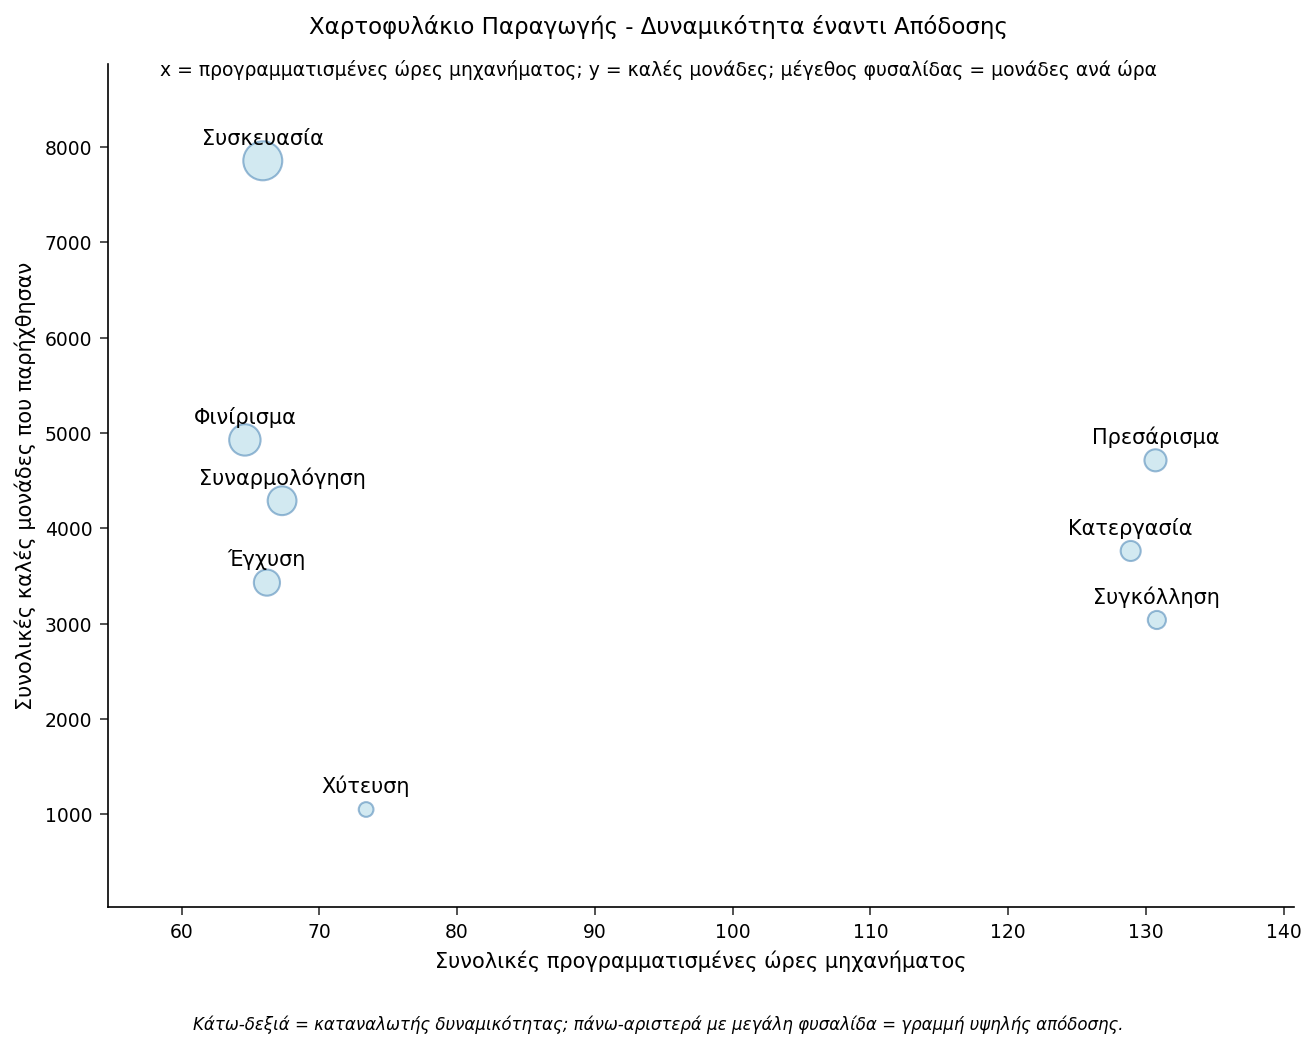

In [4]:
TITLE "Χαρτοφυλάκιο Παραγωγής - Δυναμικότητα έναντι Απόδοσης";
title2 "x = προγραμματισμένες ώρες μηχανήματος; y = καλές μονάδες; μέγεθος φυσαλίδας = μονάδες ανά ώρα";
footnote JUSTIFY=LEFT
    "Κάτω-δεξιά = καταναλωτής δυναμικότητας; πάνω-αριστερά με μεγάλη φυσαλίδα = γραμμή υψηλής απόδοσης.";

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.line_total;
    bubble x=total_capacity y=good_units size=units_per_hr /
        DATALABEL=product_line
        fillattrs=(color=cx2C5F8A)
        TRANSPARENCY=0.45;
    XAXIS ΕΤΙΚΕΤΑ="Συνολικές προγραμματισμένες ώρες μηχανήματος";
    YAXIS ΕΤΙΚΕΤΑ="Συνολικές καλές μονάδες που παρήχθησαν";
ΕΚΤΕΛΕΣΗ;

TITLE; title2; footnote;


## 5. Απόδοση ανά γραμμή, αναλυμένη ανά εργοστάσιο

Για να δούμε πώς η παραγωγή κάθε γραμμής κατανέμεται στα τρία εργοστάσια, ένα γράφημα `VBAR product_line / response=good_units group=plant` σωρεύει τις συνεισφορές των εργοστασίων εντός κάθε ράβδου. Αυτή είναι η προβολή τμηματοποίησης: δείχνει τόσο το συνολικό ύψος (καλές μονάδες ανά γραμμή) όσο και τον συνδυασμό εργοστασίων εντός κάθε ράβδου, ώστε να εντοπίζετε γραμμές όπου ένα εργοστάσιο κυριαρχεί στην παραγωγή.

                             Καλές Μονάδες ανά Γραμμή Παραγωγής, Σωρευμένες ανά Εργοστάσιο                              
                        Ύψος ράβδου = συνολικές καλές μονάδες; τμήματα = συνεισφορά εργοστασίου                         




NOTE: Option TITLE changed to Καλές Μονάδες ανά Γραμμή Παραγωγής, Σωρευμένες ανά Εργοστάσιο.
NOTE: Option TITLE2 changed to Ύψος ράβδου = συνολικές καλές μονάδες; τμήματα = συνεισφορά εργοστασίου.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


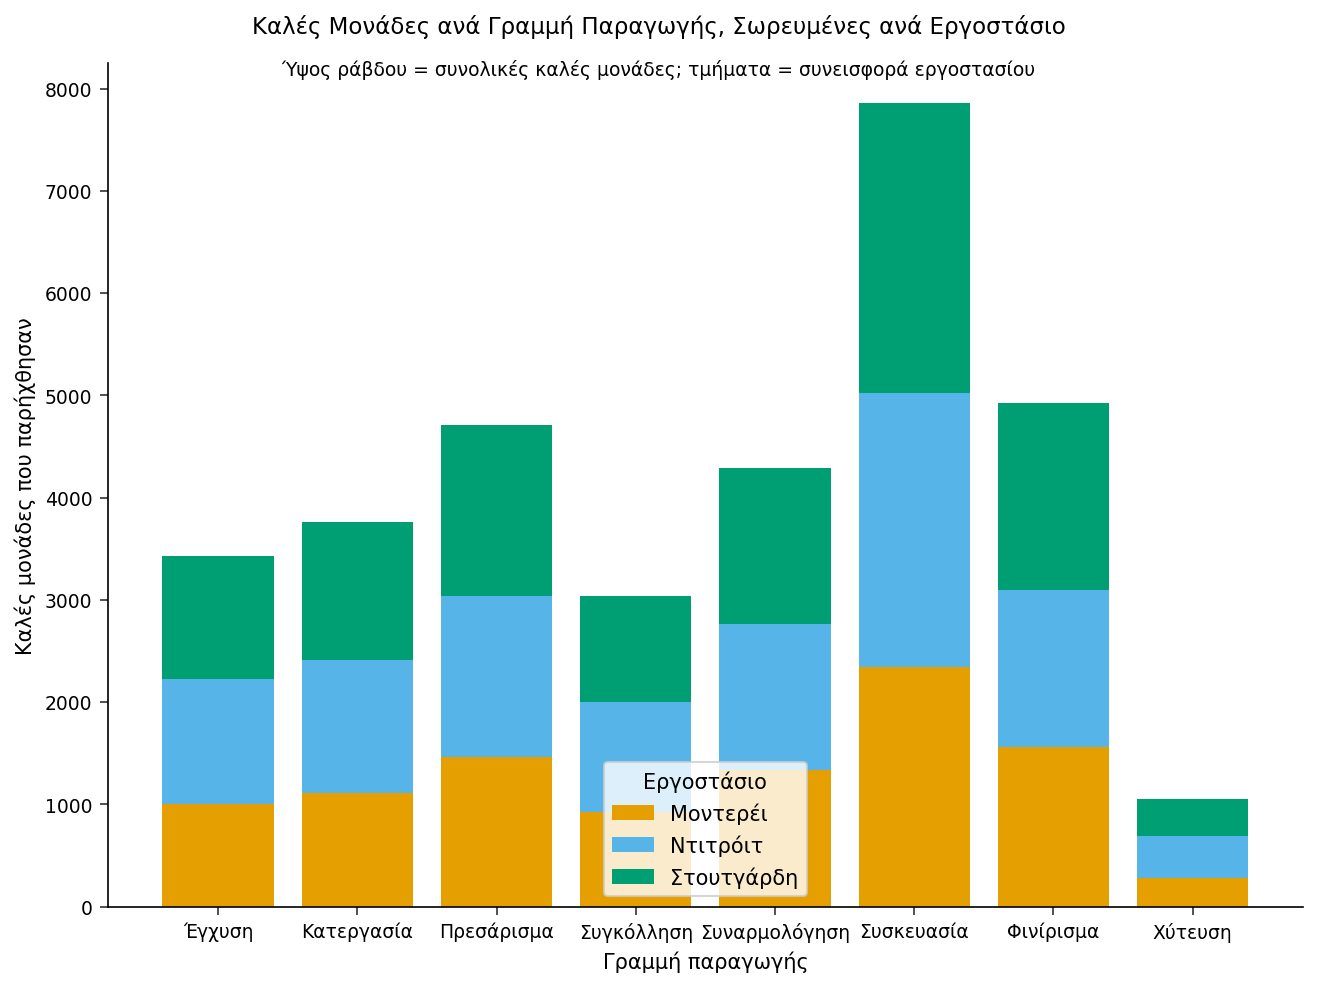

In [5]:
TITLE "Καλές Μονάδες ανά Γραμμή Παραγωγής, Σωρευμένες ανά Εργοστάσιο";
title2 "Ύψος ράβδου = συνολικές καλές μονάδες; τμήματα = συνεισφορά εργοστασίου";

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=stack;
    XAXIS ΕΤΙΚΕΤΑ="Γραμμή παραγωγής" fitpolicy=ROTATE;
    YAXIS ΕΤΙΚΕΤΑ="Καλές μονάδες που παρήχθησαν";
    keylegend / TITLE="Εργοστάσιο" position=bottom;
ΕΚΤΕΛΕΣΗ;

TITLE; title2;


## 6. Ανάλυση παραγωγικότητας ενός εργοστασίου (WHERE)

Οι οριζόντιες ράβδοι (`HBAR`) ταιριάζουν σε μακριές ετικέτες γραμμών παραγωγής. Μια ρήτρα `WHERE` περιορίζει στο εργοστάσιο της Στουτγάρδης, και οι ράβδοι σχεδιάζονται για το `units_per_hr` ώστε το γράφημα να κατατάσσει τις γραμμές της Στουτγάρδης κατά παραγωγικότητα. Επειδή η είσοδος είναι ταξινομημένη αύξουσα κατά ρυθμό, η λιγότερο παραγωγική γραμμή βρίσκεται στο κάτω μέρος και η πιο παραγωγική στην κορυφή.

                              Εργοστάσιο Στουτγάρδης - Γραμμές Κατά Σειρά Παραγωγικότητας                               


Μήκος ράβδου = καλές μονάδες ανά ώρα μηχανήματος (ανάλυση ενός εργοστασίου).



NOTE: Option TITLE changed to Εργοστάσιο Στουτγάρδης - Γραμμές Κατά Σειρά Παραγωγικότητας.
NOTE: Option FOOTNOTE changed to Μήκος ράβδου = καλές μονάδες ανά ώρα μηχανήματος (ανάλυση ενός εργοστασίου)..
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


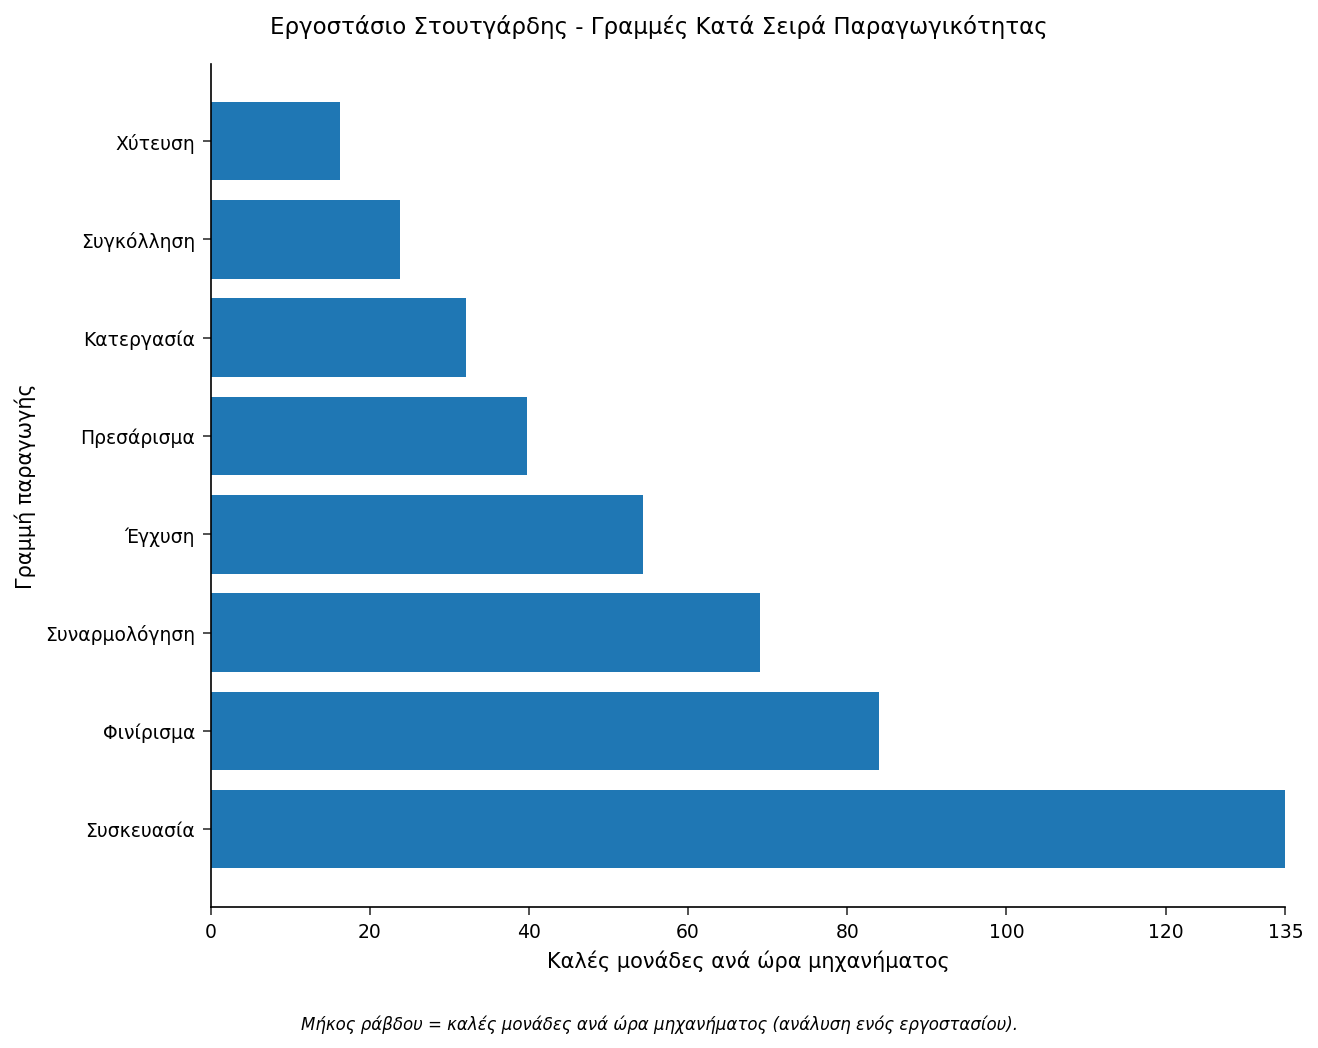

In [6]:
TITLE "Εργοστάσιο Στουτγάρδης - Γραμμές Κατά Σειρά Παραγωγικότητας";
footnote JUSTIFY=LEFT "Μήκος ράβδου = καλές μονάδες ανά ώρα μηχανήματος (ανάλυση ενός εργοστασίου).";

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.line_capacity;
    ΟΠΟΥ plant = "Στουτγάρδη";
    HBAR product_line / RESPONSE=units_per_hr
        CATEGORYORDER=respasc
        fillattrs=(color=cx28A745);
    XAXIS ΕΤΙΚΕΤΑ="Καλές μονάδες ανά ώρα μηχανήματος";
    YAXIS ΕΤΙΚΕΤΑ="Γραμμή παραγωγής";
ΕΚΤΕΛΕΣΗ;

TITLE; footnote;


## 7. Σύγκριση εργοστασίων δίπλα-δίπλα (ομαδοποιημένες ράβδοι)

Για να συγκρίνουμε τα τρία εργοστάσια γραμμή προς γραμμή, ένα ραβδόγραμμα ομαδοποιημένων ράβδων (`GROUPDISPLAY=CLUSTER`) σχεδιάζει το Ντιτρόιτ, τη Μοντερέι, και τη Στουτγάρδη ως γειτονικές ράβδους εντός κάθε γραμμής παραγωγής. Αυτή είναι η προβολή σύγκρισης ίσων όρων: για οποιαδήποτε γραμμή μπορείτε να διαβάσετε ποιο εργοστάσιο παρήγαγε τις περισσότερες καλές μονάδες, καθιστώντας τις διαφορές απόδοσης εργοστασίων (Στουτγάρδη υψηλότερη, Μοντερέι χαμηλότερη) άμεσα ορατές.

                                 Καλές Μονάδες ανά Γραμμή και Εργοστάσιο - Δίπλα-Δίπλα                                  
                     Ομαδοποιημένες ράβδοι: μία ράβδος ανά εργοστάσιο εντός κάθε γραμμής παραγωγής                      




NOTE: Option TITLE changed to Καλές Μονάδες ανά Γραμμή και Εργοστάσιο - Δίπλα-Δίπλα.
NOTE: Option TITLE2 changed to Ομαδοποιημένες ράβδοι: μία ράβδος ανά εργοστάσιο εντός κάθε γραμμής παραγωγής.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot3.svg
NOTE: ODS Graphics is OFF.


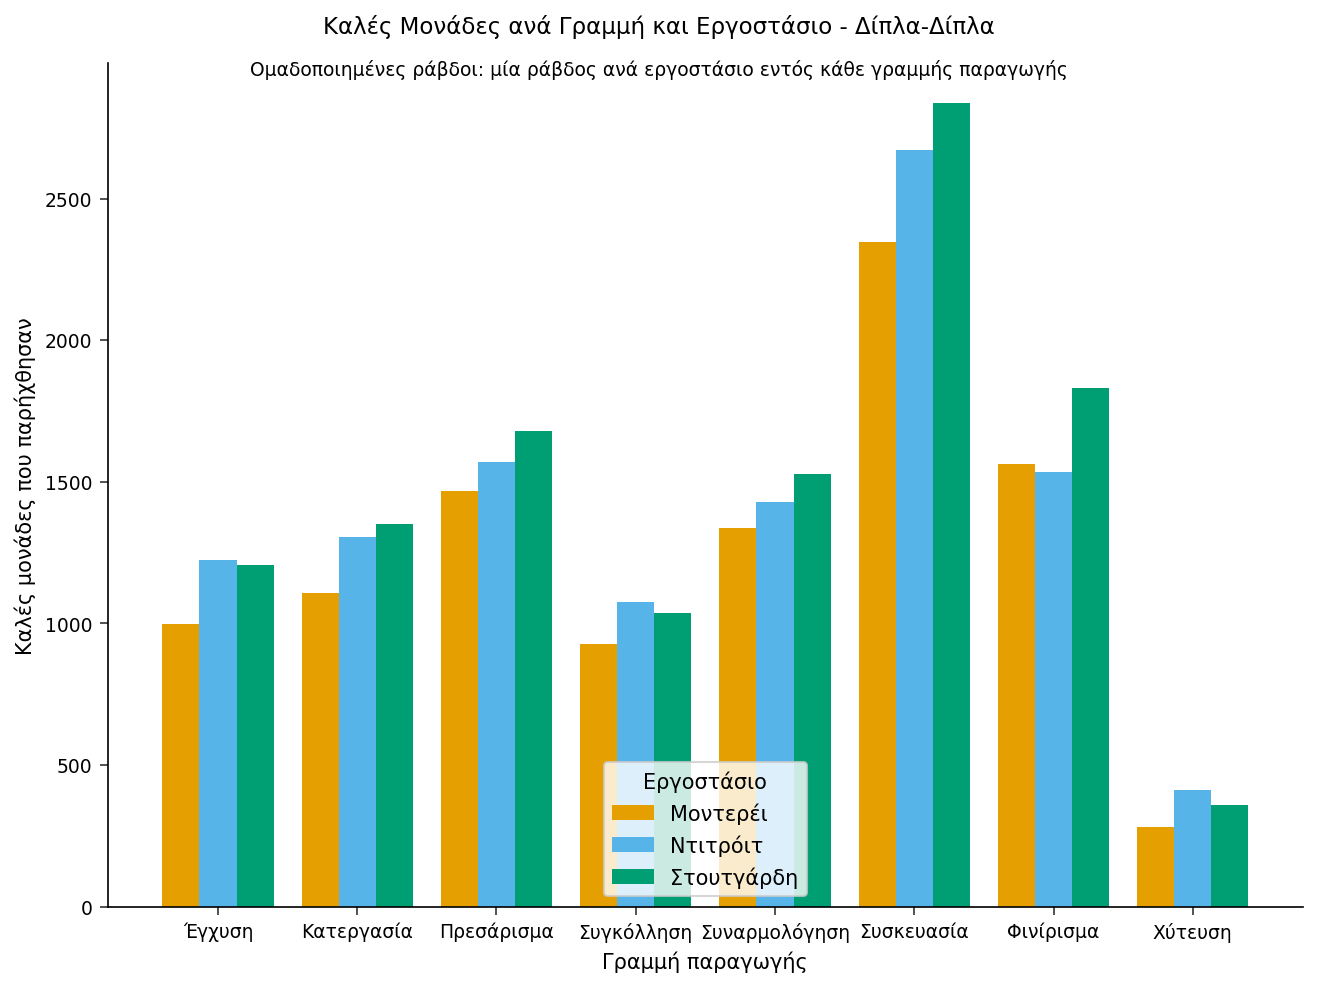

In [7]:
TITLE "Καλές Μονάδες ανά Γραμμή και Εργοστάσιο - Δίπλα-Δίπλα";
title2 "Ομαδοποιημένες ράβδοι: μία ράβδος ανά εργοστάσιο εντός κάθε γραμμής παραγωγής";

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=CLUSTER;
    XAXIS ΕΤΙΚΕΤΑ="Γραμμή παραγωγής" fitpolicy=ROTATE;
    YAXIS ΕΤΙΚΕΤΑ="Καλές μονάδες που παρήχθησαν";
    keylegend / TITLE="Εργοστάσιο" position=bottom;
ΕΚΤΕΛΕΣΗ;

TITLE; title2;

ODS GRAPHICS OFF;
ODS html CLOSE;


## Ερμηνεία

Η απεικόνιση δυναμικότητας και απόδοσης στους ίδιους άξονες αποκαλύπτει μια σχέση που ένα μονοδιάστατο ραβδόγραμμα θα έκρυβε. Η **Χύτευση** είναι ο πιο σαφής καταναλωτής δυναμικότητας του χαρτοφυλακίου: στην κατάταξη παραγωγικότητας βρίσκεται στο κάτω μέρος με **14.3 καλές μονάδες ανά ώρα μηχανήματος**, και στο διάγραμμα φυσαλίδων πέφτει κάτω-αριστερά ως μικρή φυσαλίδα — απορροφά το **10.1%** των συνολικών προγραμματισμένων ωρών αλλά αποδίδει μόνο το **3.2%** των καλών μονάδων (φέρει επίσης τη χαμηλότερη απόδοση, ~91%, λόγω του υψηλού ποσοστού απόρριψής της). Είναι ο κύριος υποψήφιος για kaizen μείωσης χρόνου κύκλου και απόρριψης. Στο αντίθετο άκρο, η **Συσκευασία** είναι η γραμμή υψηλής απόδοσης που ξεχωρίζει με **119.2 μονάδες ανά ώρα μηχανήματος** — μια μεγάλη φυσαλίδα ψηλά στον άξονα απόδοσης που μετατρέπει το **9.1%** της δυναμικότητας σε **23.8%** όλων των καλών μονάδων· η προστασία του χρόνου λειτουργίας της αποδίδει δυσανάλογη παραγωγή. Η **Φινίρισμα** (76.3 μονάδες/ώρα) και η **Συναρμολόγηση** (63.7) ακολουθούν το ίδιο μοτίβο υψηλής απόδοσης.

Το μοτίβο είναι συστηματικό: οι τέσσερις αργές, πεινασμένες για δυναμικότητα γραμμές ανάντη — Χύτευση, Συγκόλληση (23.2 μονάδες/ώρα), Κατεργασία (29.2), και Πρεσάρισμα (36.1) — καταναλώνουν μαζί περίπου το **64%** των προγραμματισμένων ωρών αλλά αποδίδουν μόνο περίπου το **38%** των καλών μονάδων, ενώ οι τέσσερις γρήγορες γραμμές κατάντη υπερ-αποδίδουν σε σχέση με τις ώρες που απορροφούν. Η προβολή σώρευσης ανά εργοστάσιο και οι ομαδοποιημένες ράβδοι δίπλα-δίπλα δείχνουν τη διάσταση εργοστασίου πίσω από αυτό: η **Στουτγάρδη** τρέχει πιο θερμά με **49.9 καλές μονάδες ανά ώρα μηχανήματος**, το **Ντιτρόιτ** είναι στη μέση με **44.9**, και η **Μοντερέι** ακολουθεί με **41.6** — συνεπές με τη μεγαλύτερη μοντελοποιημένη διακοπή λειτουργίας της Μοντερέι. Λειτουργικά, αυτό υποδεικνύει την ανακατανομή προγραμματισμένων ωρών προς τις γραμμές υψηλής απόδοσης κατάντη και τη συγκριτική αξιολόγηση της διακοπής λειτουργίας της Μοντερέι έναντι των πρακτικών της Στουτγάρδης.

*Μόνο συνθετικά δεδομένα — τα στοιχεία είναι ενδεικτικά της δισδιάστατης οπτικοποίησης δυναμικότητας-έναντι-απόδοσης με την PROC SGPLOT, όχι πραγματική απόδοση εργοστασίου.*